This section is commented out because it was just work I did to work out the fundementals.

In [ ]:
"""
#import spacy

# Load the English NLP model
nlp = spacy.load("en_core_web_sm")

def load_and_split_sentences_spacy(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
    doc = nlp(text)
    sentences = [sent.text for sent in doc.sents]
    return sentences

# Load and split sentences from both documents
doc1_sentences = load_and_split_sentences_spacy('jon.txt')
doc2_sentences = load_and_split_sentences_spacy('sam.txt')

print("Document 1 Sentences:", doc1_sentences)
print("Document 2 Sentences:", doc2_sentences)


FileNotFoundError: [Errno 2] No such file or directory: 'jon.txt'

In [ ]:
"""
from sentence_transformers import SentenceTransformer, util
import numpy as np

# Load the model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Embed sentences from both documents

embeddings1 = model.encode(doc1_sentences, convert_to_tensor=True)
embeddings2 = model.encode(doc2_sentences, convert_to_tensor=True)

# Calculate similarity matrix
cosine_scores = util.pytorch_cos_sim(embeddings1, embeddings2)

# Find similar sentences based on threshold
similar_pairs = []
threshold = 0.8
for i in range(len(doc1_sentences)):
    for j in range(len(doc2_sentences)):
        if cosine_scores[i][j] > threshold:
            similar_pairs.append((doc1_sentences[i], doc2_sentences[j]))

print("Similar sentence pairs:", similar_pairs)


Similar sentence pairs: []


In [ ]:
"""
# Define a threshold for sentence similarity
threshold = 0.5  # Adjust based on desired strictness

# Store similar sentence pairs
similar_pairs = []
for i in range(len(doc1_sentences)):
    for j in range(len(doc2_sentences)):
        if cosine_scores[i][j] > threshold:
            similar_pairs.append({
                "doc1_sentence": doc1_sentences[i],
                "doc2_sentence": doc2_sentences[j],
                "similarity_score": cosine_scores[i][j].item()
            })

# Print or save the results
print("Similar sentence pairs:", similar_pairs)

Similar sentence pairs: [{'doc1_sentence': '\ufeffHello my name is jon.', 'doc2_sentence': '\ufeffHello my name is sam.', 'similarity_score': 0.7168182134628296}]


the following is for fact checking, and is the actual project code

**PDF** **HIGHLIGHTING**

In [ ]:
!pip install sentence-transformers
!pip install fpdf2
!apt-get install -y fonts-dejavu
!pip install pymupdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.8/227.8 kB 6.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra
The following NEW packages will be installed:
  fonts-dejavu fonts-dejavu-core fonts-dejavu-extra
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 3,085 kB of archives.
After this operation, 10.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-dejavu all 2.37-2build1 [3,192 B]
Fetched 3,085 kB in 2s (1,355 kB/s)
Selecting previously unselected package fonts

Initializing the model...
Enter the paths for the reference files, separated by commas:
/content/txt1.txt,/content/txt2.txt
Enter the path for the new document file to check:
/content/checktxt.txt
Loaded 8 sentences from files.
Loaded 9 sentences from files.
Loaded 9 sentences from the document to check.
Analyzing sentences for similarity...


<ipython-input-7-e09fd5eb00d3>:44: DeprecationWarning: "uni" parameter is deprecated since v2.5.1, unused and will soon be removed
  pdf.add_font('DejaVuSans', '', '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', uni=True)
<ipython-input-7-e09fd5eb00d3>:51: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, text, ln=True)


Sentence 1/9 - Score: 0.85 - Label: Uncertain
Sentence 2/9 - Score: 0.82 - Label: Uncertain
Sentence 3/9 - Score: 1.00 - Label: True
Sentence 4/9 - Score: 0.66 - Label: Uncertain
Sentence 5/9 - Score: 0.83 - Label: Uncertain
Sentence 6/9 - Score: 0.76 - Label: Uncertain
Sentence 7/9 - Score: 0.90 - Label: True
Sentence 8/9 - Score: 0.88 - Label: True
Sentence 9/9 - Score: 0.20 - Label: False

PDF created with highlighted sentences: /content/highlighted_document.pdf


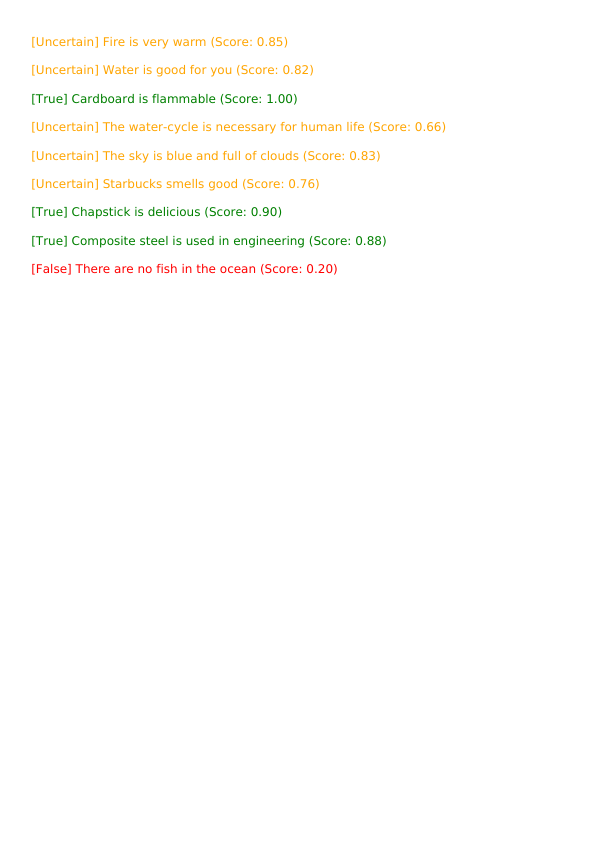

/content/highlighted_document.pdf

In [ ]:
from sentence_transformers import SentenceTransformer, util
from fpdf import FPDF
import torch
import fitz  # PyMuPDF for rendering PDF as images
from IPython.display import Image, display, FileLink

# Initialize Sentence Transformer model
print("Initializing the model...")
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Function to load and split sentences from text files
def load_and_split_sentences(file_paths):
    all_sentences = []
    for file_path in file_paths:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
            sentences = text.split('.')  # Basic sentence splitting
            all_sentences.extend([sentence.strip() for sentence in sentences if sentence.strip()])
    print(f"Loaded {len(all_sentences)} sentences from files.")
    return all_sentences

# Prompt to enter file paths for reference and new document files
print("Enter the paths for the reference files, separated by commas:")
reference_files_input = input().strip()
reference_files = [file.strip() for file in reference_files_input.split(",")]

print("Enter the path for the new document file to check:")
new_doc_file = input().strip()

# Step 3: Load reference and new document sentences
reference_sentences = load_and_split_sentences(reference_files)
reference_embeddings = model.encode(reference_sentences, convert_to_tensor=True)
new_doc_sentences = load_and_split_sentences([new_doc_file])
print(f"Loaded {len(new_doc_sentences)} sentences from the document to check.")

# Thresholds for classification
threshold_true = 0.85
threshold_uncertain = 0.65

# PDF document setup
pdf = FPDF()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_font('DejaVuSans', '', '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', uni=True)
pdf.set_font('DejaVuSans', size=12)

# Function to add colored text in PDF
def add_colored_text(pdf, text, color):
    pdf.set_text_color(*color)
    text = text.replace('\ufeff', '')  # Remove BOM if present
    pdf.cell(0, 10, text, ln=True)

# Analyze each sentence in the new document
print("Analyzing sentences for similarity...")
for idx, sentence in enumerate(new_doc_sentences, 1):
    sentence_embedding = model.encode(sentence, convert_to_tensor=True)
    cosine_scores = util.pytorch_cos_sim(sentence_embedding, reference_embeddings)
    max_score, max_index = torch.max(cosine_scores, dim=1)

    # Determine color based on threshold
    if max_score >= threshold_true:
        color = (0, 128, 0)  # Green for "True"
        label = "True"
    elif max_score >= threshold_uncertain:
        color = (255, 165, 0)  # Yellow for "Uncertain"
        label = "Uncertain"
    else:
        color = (255, 0, 0)  # Red for "False"
        label = "False"

    # Print information about each sentence
    print(f"Sentence {idx}/{len(new_doc_sentences)} - Score: {max_score.item():.2f} - Label: {label}")

    # Add sentence with appropriate color to PDF
    add_colored_text(pdf, f"[{label}] {sentence} (Score: {max_score.item():.2f})", color)

# Save the PDF
pdf_output_path = "/content/highlighted_document.pdf"
pdf.output(pdf_output_path)
print(f"\nPDF created with highlighted sentences: {pdf_output_path}")

# Function to display PDF as images in Colab
def display_pdf_as_images(pdf_path):
    pdf_document = fitz.open(pdf_path)
    for page_num in range(len(pdf_document)):
        page = pdf_document[page_num]
        pix = page.get_pixmap()
        image_path = f"/content/page_{page_num + 1}.png"
        pix.save(image_path)
        display(Image(filename=image_path))

# Display the generated PDF
display_pdf_as_images(pdf_output_path)

# Download link for the PDF
display(FileLink(pdf_output_path))


Fine Tuning

In [ ]:
!pip install -U sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 3.2.1
    Uninstalling sentence-transformers-3.2.1:
      Successfully uninstalled sentence-transformers-3.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of th

In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from torch.utils.data import DataLoader
from datasets import load_dataset

# Load the FEVER dataset with specified config
fever = load_dataset("fever", "v1.0")

# Initialize the SentenceTransformer model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Preprocess the FEVER dataset into InputExample format
def prepare_fever_examples(data):
    examples = []
    for item in data:
        # Label encoding: Supported=1.0, Refuted=0.0, Not Enough Information=0.5
        if item['label'] == "SUPPORTS":
            label = 1.0
        elif item['label'] == "REFUTES":
            label = 0.0
        else:
            label = 0.5

        # Check if 'evidence_sentence_id' exists and is usable
        evidence = str(item['evidence_sentence_id']) if item['evidence_sentence_id'] is not None else "No evidence provided"

        # Create InputExample with claim and evidence
        examples.append(InputExample(texts=[item['claim'], evidence], label=label))

    return examples

train_subset = fever['train'].shuffle(seed=42).select(range(10000))  # First 10,000 examples
val_subset = fever['labelled_dev'].shuffle(seed=42).select(range(2000))  # First 2,000 examples

# Prepare training and validation data
train_examples = prepare_fever_examples(train_subset)
val_examples = prepare_fever_examples(val_subset)

# Create DataLoader for training
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8)
train_loss = losses.CosineSimilarityLoss(model=model)

# Define evaluator for validation
val_evaluator = evaluation.EmbeddingSimilarityEvaluator.from_input_examples(val_examples, name="fever-val")

# Fine-tune the model
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=val_evaluator,
    epochs=3,  # Increase for longer training
    evaluation_steps=2000,  # Evaluate every 2000 steps
    output_path="output/fever_finetuned_model"
)

print("Model fine-tuning with FEVER completed!")




/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

fever.py:   0%|          | 0.00/10.2k [00:00<?, ?B/s]

The repository for fever contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/fever.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/311431 [00:00<?, ? examples/s]

...

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss,Validation Loss,Fever-val Pearson Cosine,Fever-val Spearman Cosine
1250,0.133900,No log,0.503758,0.487160
2000,0.113800,No log,0.552436,0.544445
2500,0.103600,No log,0.577970,0.587400
3750,0.094300,No log,0.596462,0.606656


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Model fine-tuning with FEVER completed!


Retest PDF Highlighting

Initializing the fine-tuned model...
Enter the paths for the reference files, separated by commas:
/content/txt1.txt,/content/txt2.txt
Enter the path for the new document file to check:
/content/checktxt.txt
Loaded 8 sentences from files.
Loaded 9 sentences from files.
Loaded 9 sentences from the document to check.
Analyzing sentences for similarity...


<ipython-input-6-7cd9f14a3398>:44: DeprecationWarning: "uni" parameter is deprecated since v2.5.1, unused and will soon be removed
  pdf.add_font('DejaVuSans', '', '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', uni=True)
<ipython-input-6-7cd9f14a3398>:51: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, text, ln=True)


Sentence 1/9 - Score: 0.85 - Label: Uncertain
Sentence 2/9 - Score: 0.93 - Label: True
Sentence 3/9 - Score: 1.00 - Label: True
Sentence 4/9 - Score: 0.89 - Label: True
Sentence 5/9 - Score: 0.94 - Label: True
Sentence 6/9 - Score: 0.84 - Label: Uncertain
Sentence 7/9 - Score: 0.92 - Label: True
Sentence 8/9 - Score: 0.94 - Label: True
Sentence 9/9 - Score: 0.25 - Label: False

PDF created with highlighted sentences: /content/highlighted_document.pdf


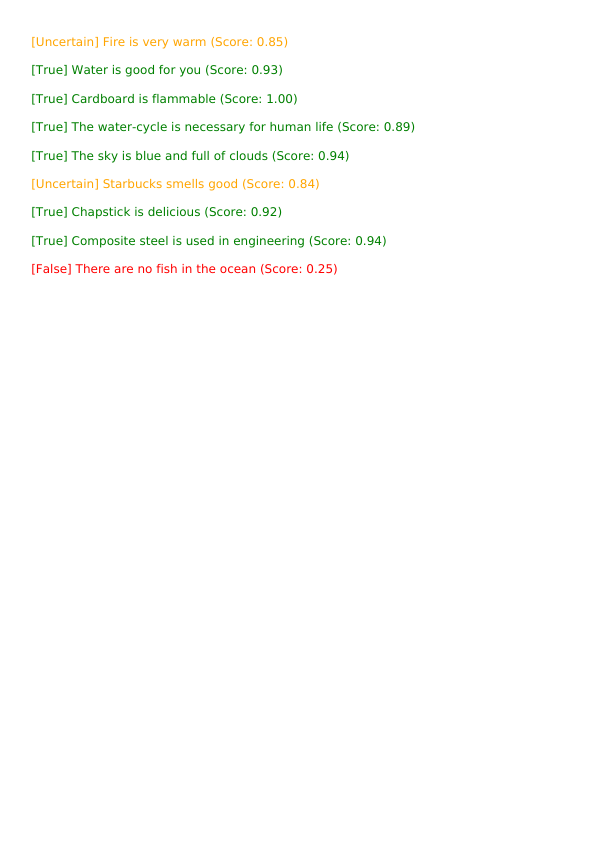

/content/highlighted_document.pdf

In [ ]:
from sentence_transformers import SentenceTransformer, util
from fpdf import FPDF
import torch
import fitz  # PyMuPDF for rendering PDF as images
from IPython.display import Image, display, FileLink

# Initialize the fine-tuned Sentence Transformer model
print("Initializing the fine-tuned model...")
model = SentenceTransformer('/content/output/fever_finetuned_model')  # Path to the fine-tuned model

# Function to load and split sentences from text files
def load_and_split_sentences(file_paths):
    all_sentences = []
    for file_path in file_paths:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
            sentences = text.split('.')  # Basic sentence splitting
            all_sentences.extend([sentence.strip() for sentence in sentences if sentence.strip()])
    print(f"Loaded {len(all_sentences)} sentences from files.")
    return all_sentences

# Prompt user to enter file paths for reference and new document files
print("Enter the paths for the reference files, separated by commas:")
reference_files_input = input().strip()
reference_files = [file.strip() for file in reference_files_input.split(",")]

print("Enter the path for the new document file to check:")
new_doc_file = input().strip()

# Step 3: Load reference and new document sentences
reference_sentences = load_and_split_sentences(reference_files)
reference_embeddings = model.encode(reference_sentences, convert_to_tensor=True)
new_doc_sentences = load_and_split_sentences([new_doc_file])
print(f"Loaded {len(new_doc_sentences)} sentences from the document to check.")

# Thresholds for classification
threshold_true = 0.85
threshold_uncertain = 0.65

# PDF document setup
pdf = FPDF()
pdf.add_page()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_font('DejaVuSans', '', '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', uni=True)
pdf.set_font('DejaVuSans', size=12)

# Function to add colored text in PDF
def add_colored_text(pdf, text, color):
    pdf.set_text_color(*color)
    text = text.replace('\ufeff', '')  # Remove BOM if present
    pdf.cell(0, 10, text, ln=True)

# Analyze each sentence in the new document
print("Analyzing sentences for similarity...")
for idx, sentence in enumerate(new_doc_sentences, 1):
    sentence_embedding = model.encode(sentence, convert_to_tensor=True)
    cosine_scores = util.pytorch_cos_sim(sentence_embedding, reference_embeddings)
    max_score, max_index = torch.max(cosine_scores, dim=1)

    # Determine color based on threshold
    if max_score >= threshold_true:
        color = (0, 128, 0)  # Green for "True"
        label = "True"
    elif max_score >= threshold_uncertain:
        color = (255, 165, 0)  # Yellow for "Uncertain"
        label = "Uncertain"
    else:
        color = (255, 0, 0)  # Red for "False"
        label = "False"

    # Print information about each sentence
    print(f"Sentence {idx}/{len(new_doc_sentences)} - Score: {max_score.item():.2f} - Label: {label}")

    # Add sentence with appropriate color to PDF
    add_colored_text(pdf, f"[{label}] {sentence} (Score: {max_score.item():.2f})", color)

# Save the PDF
pdf_output_path = "/content/highlighted_document.pdf"
pdf.output(pdf_output_path)
print(f"\nPDF created with highlighted sentences: {pdf_output_path}")

# Function to display PDF as images in Colab
def display_pdf_as_images(pdf_path):
    pdf_document = fitz.open(pdf_path)
    for page_num in range(len(pdf_document)):
        page = pdf_document[page_num]
        pix = page.get_pixmap()
        image_path = f"/content/page_{page_num + 1}.png"
        pix.save(image_path)
        display(Image(filename=image_path))

# Display the generated PDF
display_pdf_as_images(pdf_output_path)

# Download link for the PDF
display(FileLink(pdf_output_path))


The following was to look into the FEVER dataset I used.

In [ ]:
'''
# Install necessary libraries
!pip install datasets pandas

# Import required libraries
from datasets import load_dataset
import pandas as pd

# Load the FEVER dataset
# You can choose among 'v1.0', 'v2.0', or 'wiki_pages' depending on your needs
print("Loading the FEVER dataset...")
fever_dataset = load_dataset("fever", "v1.0")

# Function to display a specific subset of the dataset
def display_subset(dataset, subset_name, num_rows=10):
    """
    Display the first few rows of a specific subset of the FEVER dataset.

    Args:
        dataset: The dataset object.
        subset_name: The subset name ('train', 'labelled_dev', etc.).
        num_rows: The number of rows to display.
    """
    if subset_name in dataset:
        print(f"\nDisplaying the first {num_rows} rows of the '{subset_name}' subset:")
        df = pd.DataFrame(dataset[subset_name])
        display(df.head(num_rows))
    else:
        print(f"Subset '{subset_name}' not found in the dataset!")

# List available subsets
print("\nAvailable subsets in the FEVER dataset:")
for subset_name in fever_dataset.keys():
    print(f"- {subset_name}")

# Display a few rows of each subset
for subset_name in fever_dataset.keys():
    display_subset(fever_dataset, subset_name)


Loading the FEVER dataset...

Available subsets in the FEVER dataset:
- train
- labelled_dev
- unlabelled_dev
- unlabelled_test
- paper_dev
- paper_test

Displaying the first 10 rows of the 'train' subset:


,id,label,claim,evidence_annotation_id,evidence_id,evidence_wiki_url,evidence_sentence_id
0,75397,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broa...,92206,104971,Nikolaj_Coster-Waldau,7
1,75397,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broa...,92206,104971,Fox_Broadcasting_Company,-1
2,150448,SUPPORTS,Roman Atwood is a content creator.,174271,187498,Roman_Atwood,1
3,150448,SUPPORTS,Roman Atwood is a content creator.,174271,187499,Roman_Atwood,3
4,214861,SUPPORTS,"History of art includes architecture, dance, s...",255136,254645,History_of_art,2
5,156709,REFUTES,Adrienne Bailon is an accountant.,180804,193183,Adrienne_Bailon,-1
6,83235,NOT ENOUGH INFO,System of a Down briefly disbanded in limbo.,100277,-1,,-1
7,129629,SUPPORTS,Homeland is an American television spy thrille...,151831,166598,Homeland_-LRB-TV_series-RRB-,-1
8,129629,SUPPORTS,Homeland is an American television spy thrille...,151831,166598,Prisoners_of_War_-LRB-TV_series-RRB-,-1
9,149579,NOT ENOUGH INFO,Beautiful reached number two on the Billboard ...,173384,-1,,-1



Displaying the first 10 rows of the 'labelled_dev' subset:


,id,label,claim,evidence_annotation_id,evidence_id,evidence_wiki_url,evidence_sentence_id
0,91198,NOT ENOUGH INFO,Colin Kaepernick became a starting quarterback...,108548,-1,,-1
1,194462,NOT ENOUGH INFO,Tilda Swinton is a vegan.,227768,-1,,-1
2,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,289914,283015,Soul_Food_-LRB-film-RRB-,-1
3,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,291259,284217,Soul_Food_-LRB-film-RRB-,-1
4,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,293412,285960,Soul_Food_-LRB-film-RRB-,-1
5,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,337212,322620,Soul_Food_-LRB-film-RRB-,-1
6,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,337214,322622,Soul_Food_-LRB-film-RRB-,-1
7,166626,NOT ENOUGH INFO,Anne Rice was born in New Jersey.,191656,-1,,-1
8,166626,NOT ENOUGH INFO,Anne Rice was born in New Jersey.,191657,-1,,-1
9,111897,REFUTES,Telemundo is a English-language television net...,131371,146144,Telemundo,-1



Displaying the first 10 rows of the 'unlabelled_dev' subset:


...

,id,label,claim,evidence_annotation_id,evidence_id,evidence_wiki_url,evidence_sentence_id
0,89296,,Henry Spencer is played by a Greek actor.,-1,-1,,-1
1,78554,,John Ritter died in October.,-1,-1,,-1
2,83809,,13 Reasons Why is the only television series o...,-1,-1,,-1
3,49758,,Playboy is a magazine.,-1,-1,,-1
4,22973,,Alternative metal is the genre in which Alice ...,-1,-1,,-1
5,181494,,Sam Peckinpah directed The Wild Bunch.,-1,-1,,-1
6,161592,,The St. John's water dog is a breed of domesti...,-1,-1,,-1
7,117342,,Horseshoe crabs are not used in fertilizer.,-1,-1,,-1
8,172204,,Sia (musician) has received an award presented...,-1,-1,,-1
9,95552,,Artificial intelligence raises concern.,-1,-1,,-1



Displaying the first 10 rows of the 'paper_dev' subset:


,id,label,claim,evidence_annotation_id,evidence_id,evidence_wiki_url,evidence_sentence_id
0,91198,NOT ENOUGH INFO,Colin Kaepernick became a starting quarterback...,108548,-1,,-1
1,194462,NOT ENOUGH INFO,Tilda Swinton is a vegan.,227768,-1,,-1
2,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,289914,283015,Soul_Food_-LRB-film-RRB-,-1
3,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,291259,284217,Soul_Food_-LRB-film-RRB-,-1
4,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,293412,285960,Soul_Food_-LRB-film-RRB-,-1
5,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,337212,322620,Soul_Food_-LRB-film-RRB-,-1
6,137334,SUPPORTS,Fox 2000 Pictures released the film Soul Food.,337214,322622,Soul_Food_-LRB-film-RRB-,-1
7,166626,NOT ENOUGH INFO,Anne Rice was born in New Jersey.,191656,-1,,-1
8,166626,NOT ENOUGH INFO,Anne Rice was born in New Jersey.,191657,-1,,-1
9,111897,REFUTES,Telemundo is a English-language television net...,131371,146144,Telemundo,-1



Displaying the first 10 rows of the 'paper_test' subset:


,id,label,claim,evidence_annotation_id,evidence_id,evidence_wiki_url,evidence_sentence_id
0,113501,NOT ENOUGH INFO,Grease had bad reviews.,133128,-1,,-1
1,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...,296950,288668,Ukrainian_Soviet_Socialist_Republic,7
2,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...,298602,290067,Ukrainian_Soviet_Socialist_Republic,7
3,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...,298602,290067,United_Nations,-1
4,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...,300696,291816,Ukrainian_Soviet_Socialist_Republic,7
5,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...,344347,327887,Ukrainian_Soviet_Socialist_Republic,7
6,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...,344994,328433,Ukrainian_Soviet_Socialist_Republic,7
7,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...,344997,328435,Ukrainian_Soviet_Socialist_Republic,7
8,70041,SUPPORTS,2 Hearts is a musical composition by Minogue.,225394,230056,2_Hearts_-LRB-Kylie_Minogue_song-RRB-,-1
9,70041,SUPPORTS,2 Hearts is a musical composition by Minogue.,317953,306972,2_Hearts_-LRB-Kylie_Minogue_song-RRB-,-1
